In [ ]:
# These two lines allow for the notebook to automatically update to use the most
# up-to-date versions of the code being imported
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')
import control as ct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from pyphotonicsims.laser_dynamics.brillouin_laser import *


# plt.style.available
%matplotlib inline
plt.style.use('science')
plt.rcParams['text.usetex'] = False
plt.rcParams['figure.figsize'] = [6,5]
plt.rcParams['figure.dpi'] = 300
import matplotlib
matplotlib.rcParams['text.usetex'] = False

## Stimulated Brillouin scattering (SBS) laser model is based on Ryan O. Behunin's paper.
#### Behunin, Ryan O., et al. "Fundamental noise dynamics in cascaded-order Brillouin lasers." Physical Review A 98.2 (2018): 023832.
#### Laser rate equations for SBS cascaded emission
$$\frac{da_m}{dt} = (i\Delta\omega - \gamma/2 + \mu(|a_{m-1}|^2 - |a_{m+1}|^2))a_m + \delta_{m0}i\sqrt(\gamma_{ex})F$$
#### Laser metrics caculation: cavity Q, threshold $P_{th}$, efficiency $\eta$, minimum ST linewidth $\nu_{ST}$
$$P_{th} = \frac{h\nu\gamma^3}{8\mu\gamma_{ex}} $$
$$\eta_{S1} = (\frac{\gamma_{ex}}{\gamma})^2$$
$$\nu_{ST,min} = \frac{n_0\gamma}{2\pi}$$

In [2]:
# # 400 MQ
# r = [0.9, 0.4]          # loss rates = [intrinsic, coupling] in MHz
# L = 2*np.pi*11.787e-3   # cavity length in meter
# vST_min = 0.3           # minimum S1 ST linewidth in Hz

# # 70 MQ
# r = [1.8, 1.8]
# L = 2*np.pi*11.787e-3
# vST_min = 0.7

# # 30 MQ OR3
# r = [3.5, 3.5]
# L = 2*np.pi*11.787e-3
# vST_min = 0.7

# double-ring 80nm TM SBS at 1570
r = [1.7, 1.2]
L = 2*np.pi*11.787e-3
vST_min = 0.5

# # 800MQ 4 meter fiber cavity at 1550
# r = [0.30, 0.40]
# L = 2*np.pi*11.787e-3
# vST_min = 0.007

# # 300MQ 4 meter coil
# r = [1.0, 1.0]
# L = 4.
# vST_min = 0.01

# # 100MQ 3mm radius SBS
# r = [3.2, 3.8]
# L = 2*np.pi*2.710e-3
# vST_min = 1.0

sbs = SBSLaser(ord = 3, r = r, L = L, vST_min = vST_min)

-----------------REPORT------------------
Cavity Q:      66.70 M
P_th:          2.365 mW
min FLW:       0.500 Hz
S1 efficiency: 0.171
rho:           10.481
GB:            0.157


#### Pump power sweep from 0 mW to $10\times P_{th}$, showing thresholding and linewidth narrowing behaviors 
- Power conversion: $P_{Si}$ Stokes power, $P_{disp}$ dissipated power due to cavity intrinsic loss
$$P_{pump, in} = P_{pump, out} + \sum_i P_{Si} + P_{disp}$$
- ST linewidth narrowing
$$\nu_{m,ST} = \frac{n_0(\gamma + 4\mu|a_{m+1}|^2)}{4\pi |a_m|^2}$$

In [3]:
Px = np.linspace(0,30*sbs.P_th,500)
# sbs.pump_sweep_visulization(Px)

sbs = SBSLaser(ord = 5, r = r, L = L, vST_min = vST_min)
Pout, vST, _, _, _ = sbs.pump_detuning_sweep(Px)

# plt.savefig('sbs_laser_pump_sweep.png', dpi = 1000, bbox_inches = 'tight')

-----------------REPORT------------------
Cavity Q:      66.70 M
P_th:          2.365 mW
min FLW:       0.500 Hz
S1 efficiency: 0.171
rho:           10.481
GB:            0.157


### S2 suppression

In [4]:
### S2 suppression
sbs_S1 = SBSLaser(ord = 2, r = r, L = L, vST_min = vST_min)
Pout_1, vST_1, _, _, _ = sbs_S1.pump_detuning_sweep(Px)

-----------------REPORT------------------
Cavity Q:      66.70 M
P_th:          2.365 mW
min FLW:       0.500 Hz
S1 efficiency: 0.171
rho:           10.481
GB:            0.157


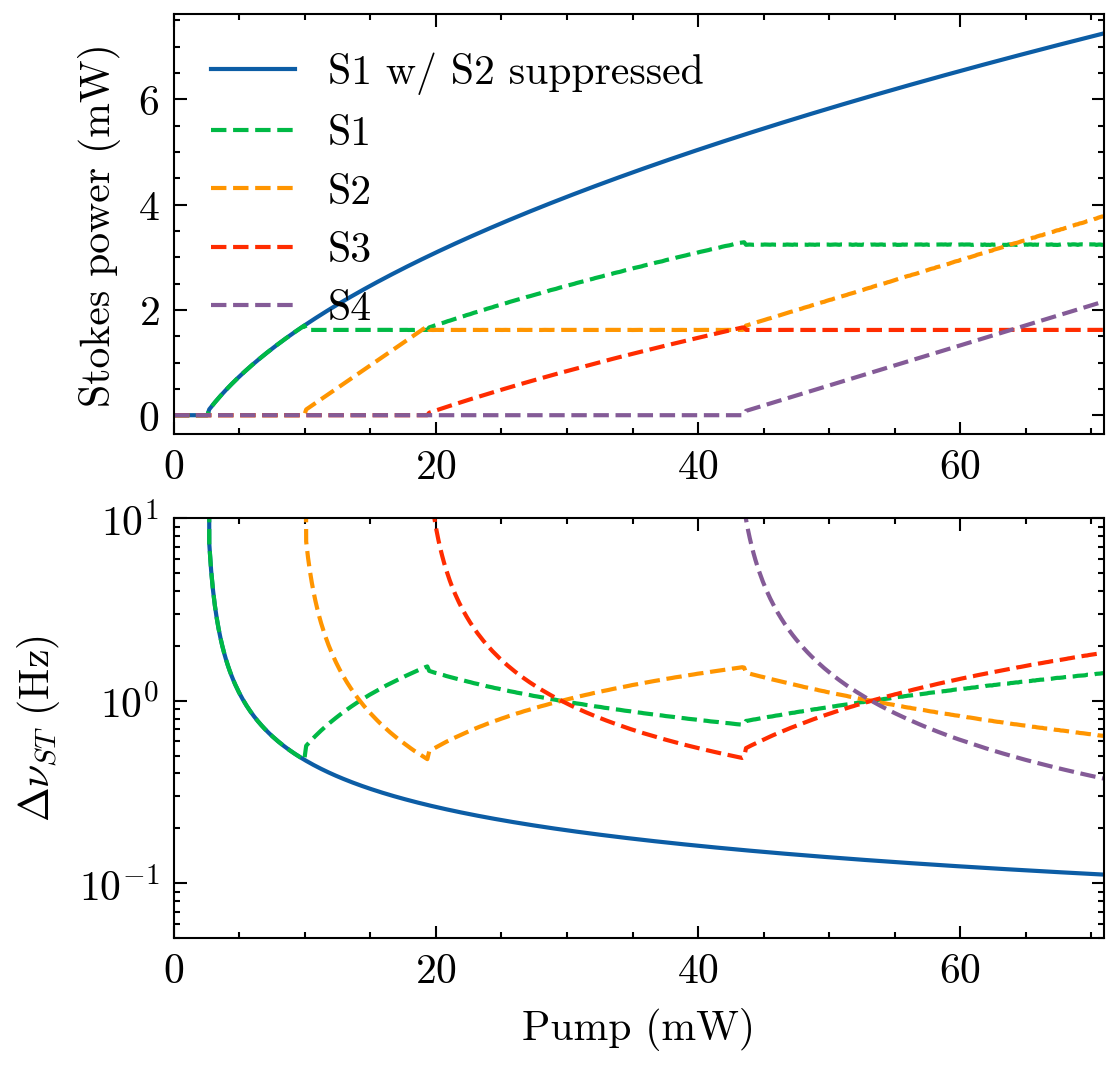

In [5]:
plt.figure(figsize=[4, 4])
plt.subplot(211)
plt.plot(Px * 1e3, Pout_1[1, :].T*1e3)
plt.plot(Px * 1e3, Pout[1:-3, :].T*1e3, '--')
plt.xlim((0, Px[-1]*1e3))
plt.ylabel('Stokes power (mW)')
plt.legend(('S1 w/ S2 suppressed', 'S1', 'S2', 'S3', 'S4'))
plt.subplot(212)
plt.semilogy(Px * 1e3, vST_1[0, :])
plt.semilogy(Px * 1e3, vST.T, '--')
plt.xlim((0, Px[-1]*1e3))
plt.ylim((sbs.vST_min/10, 10))
plt.xlabel('Pump (mW)')
plt.ylabel(r'$\Delta\nu_{ST}$' + ' (Hz)')

plt.savefig('sbs_S2_suppressed.png', dpi = 1000, bbox_inches = 'tight')

### S3 suppression

In [ ]:
### S3 suppression
sbs_S1_S2 = SBSLaser(ord = 3, r = r, L = L, vST_min = vST_min)
Pout_2, vST_2, _, _, _ = sbs_S1_S2.pump_detuning_sweep(Px)

-----------------REPORT------------------
Cavity Q:      66.70 M
P_th:          2.365 mW
min FLW:       0.500 Hz
S1 efficiency: 0.171
rho:           10.481
GB:            0.157


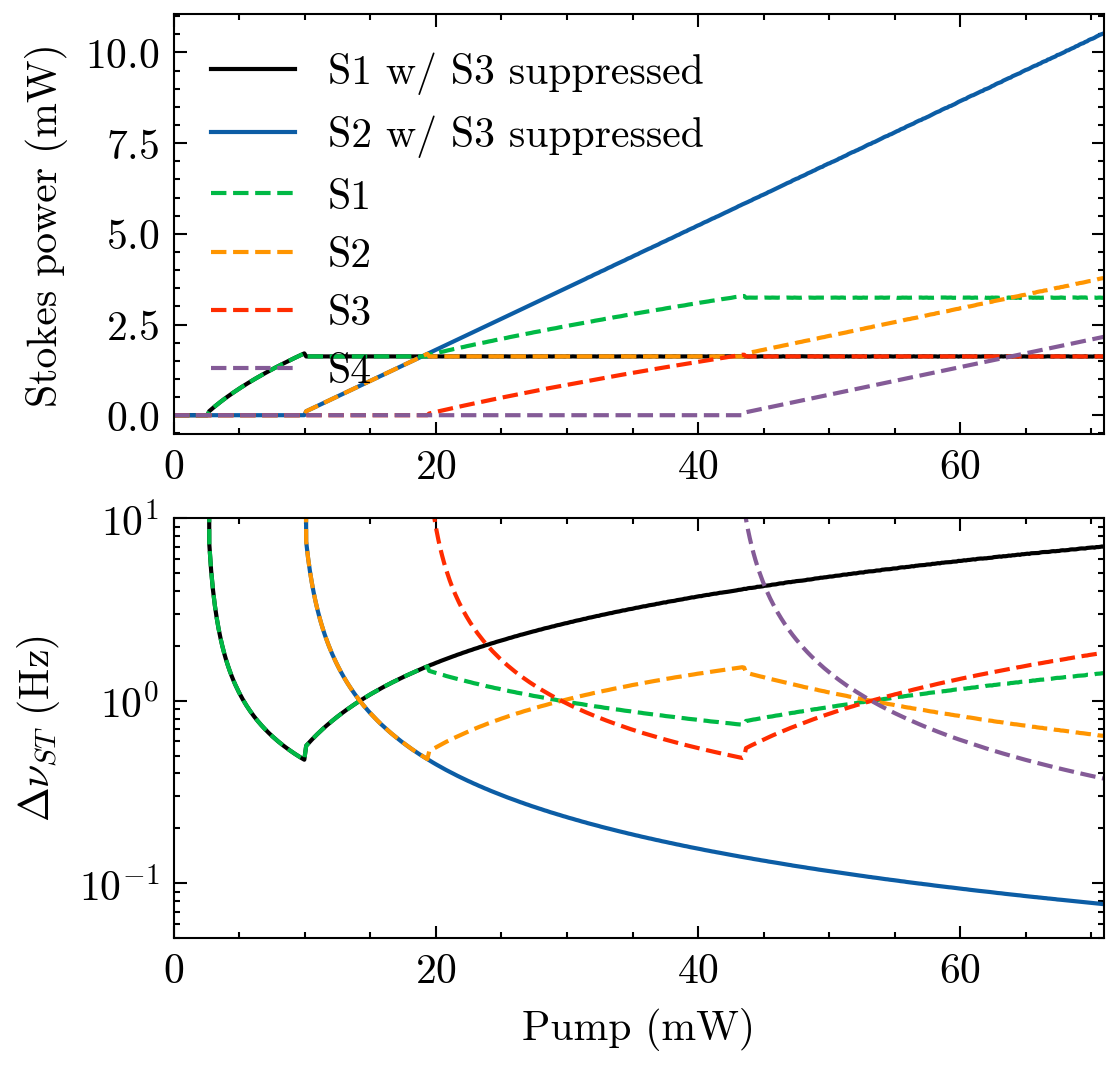

In [ ]:
plt.figure(figsize=[4, 4])
plt.subplot(211)
plt.plot(Px * 1e3, Pout_2[1, :].T*1e3, color = 'k')
plt.plot(Px * 1e3, Pout_2[2, :].T*1e3)
plt.plot(Px * 1e3, Pout[1:-3, :].T*1e3, '--')
plt.xlim((0, Px[-1]*1e3))
plt.ylabel('Stokes power (mW)')
plt.legend(('S1 w/ S3 suppressed', 'S2 w/ S3 suppressed', 'S1', 'S2', 'S3', 'S4'))
plt.subplot(212)
plt.semilogy(Px * 1e3, vST_2[0, :], color = 'k')
plt.semilogy(Px * 1e3, vST_2[1, :])
plt.semilogy(Px * 1e3, vST.T, '--')
plt.xlim((0, Px[-1]*1e3))
plt.ylim((sbs.vST_min/10, 10))
plt.xlabel('Pump (mW)')
plt.ylabel(r'$\Delta\nu_{ST}$' + ' (Hz)')

plt.savefig('sbs_S3_suppressed.png', dpi = 1000, bbox_inches = 'tight')